In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
import pandas as pd

df = pd.read_csv("H2_atmosphere_1_M_earth_1_F_earth - H2_atmosphere_1_M_earth_1_F_earth.csv")

rho_H2_1M_1F = df["Density [kg/m3]"].tolist()
rho_H2_1M_1F = np.array(rho_H2_1M_1F)[-1]


In [4]:
# R = 8.31446 # J/K/mol

# def rho_atm(P, mmw, R, T):
#     """"""
#     rho = (P*mmw) / (R*T)
    
#     return rho

# formula unneeded, gives rho_atmosphere.

# H2 atmosphere

M_1E = 5.97e25 # kg
R_1E = 1.185006e11 # km

M_10E = 5.97e24 # kg
R_10E = 6.311626946e9 # km


# R = 6378 # radius earth [km]
# M_planet = 5.98e24 # mass earth [kg]
h = 8.5 # scaleheight earth [km]
M_atm = 5.15e18 # earth atmosphere mass [kg]
M0 = M_atm
# rho_0 = 1.293e9 # density at earth surface [kg/km^3]
rho = 2e12 # density of planetesimal [kg/km^3]




# QUESTION: R_obs or R_int


# CO2 atmosphere:

In [5]:
def rho_atmos(filename):
    """"""
    df = pd.read_csv(filename)
    
    df["Density [kg/m3]"].tolist()

In [12]:

N_0 = 1 # impactor flux
r_0 = 1 # impactor radius 

def dM_atmos(q, C, R, rho_0):
    """Atmospheric mass loss through impactors"""
    if q >= 3:
        r_min = (3*rho_0/rho)**(1/3)*h
        m_min = 4*np.pi*rho_0*h**3
        
        dM = - np.pi * R**2 * ((N_0*m_min)/(q-3)) * (r_min/r_0)**(-q+1)
        
    elif 3 > q > 1:
        r_cap = (3*np.sqrt(2*np.pi)*rho_0 / (4*rho))**(1/3) * (h*R)**(1/2)
        M_cap = 2*np.pi*rho_0*(h**2)*R
        
        # dM = - np.pi * R**2 * C * N_0 * M_cap * (r_cap/r_0)**(-q+1)
        dM = np.pi * R**2 * C * N_0 * M_cap * (r_cap/r_0)**(-q+1)
        
    return dM


In [10]:
q = [4.5, 4.0, 3.5, 3.1, 2.8, 2.5, 2.0, 1.5] # 4.5
C = [None, None, None, None, 2.8, 1.9, 1.3, 1.1] # None

# q = [2.8, 2.5, 2.0, 1.5] # 4.5
# C = [2.8, 1.9, 1.3, 1.1] # None

dM_list = []

for i in range(len(q)):
    dM = dM_atmos(q[i], C[i], R_1E, rho_H2_1M_1F)
    print(dM)
    dM_list.append(dM)
    
dM = np.array(dM_list)


-4.6379229544032136e+36
-3.6958094896665535e+35
-3.9267600082177815e+34
-1.876031790754193e+34
6.176711235317562e+33
2.284956718818735e+34
2.640034364253905e+35
3.7722525710610025e+36


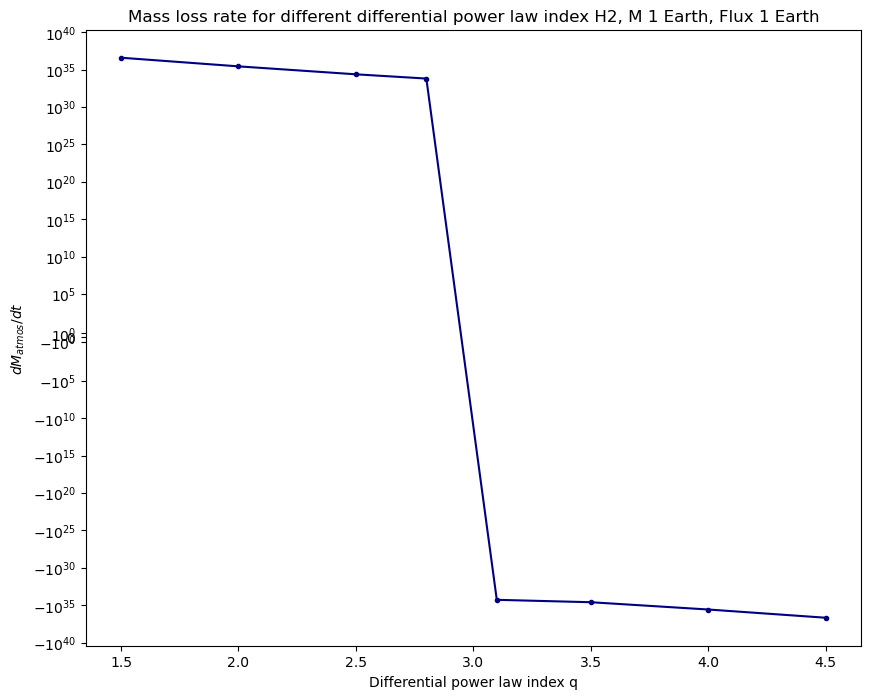

In [11]:
plt.figure(figsize=(10,8))
plt.plot(q, dM, color='navy', marker='.')
plt.xlabel('Differential power law index q')
plt.ylabel(r'$dM_{atmos}/dt$')
plt.title(r'Mass loss rate for different differential power law index H2, M 1 Earth, Flux 1 Earth')
plt.yscale('symlog')
# plt.legend()
# plt.savefig('Mtotal_vs_impactor_rad')
plt.show()


In [ ]:
r_min = r_min = (3*rho_0/rho)**(1/3)*h # minimum impact size [km] ~ 1 km

r_cap = (3*np.sqrt(2*np.pi)*rho_0 / (4*rho))**(1/3) * (h*R)**(1/2) # cap size [km] ~ 25 km

r_gi = (2 * h * (R**2))**(1/3) # where giant impacts dominate [km]


# print(r_gi) # print giant impact mass, should be ~900 km

r = np.geomspace((r_min + 0.00001),3000,1000) # set up x-axis scale (log)
# print(r)


In [ ]:
plt.figure(figsize=(10,8))
plt.plot(r, MT_Mp, color='navy')
plt.xlabel('r [km]')
plt.axvline(r_min, label=r'$r_{min}$', color='tomato', linestyle='--', alpha=0.7)
plt.axvline(r_cap, label=r'$r_{cap}$', color='orange', linestyle='-.', alpha=0.7)
plt.axvline(r_gi,label=r'$r_{gi}$' , color='turquoise', linestyle=':', alpha=0.7)
plt.ylabel(r'$M_T/M_{earth}$')
plt.title(r'Total impactor mass $M_T$ needed to eject atmosphere as function of impactor radius r (fig 14)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
# plt.savefig('Mtotal_vs_impactor_rad')
plt.show()
